# Olist — Pre-processamento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

PASTA  = './archive/'
df_raw = pd.read_csv(PASTA + 'dataset_features.csv')
df     = df_raw.copy()

print(f'{df.shape[0]:,} linhas x {df.shape[1]} colunas')
df.head(3)

96,412 linhas x 34 colunas


,order_id,customer_id,dias_entrega,hora_compra,dia_semana_compra,mes_compra,eh_fim_de_semana,horas_ate_aprovacao,horas_ate_transportadora,qtd_itens,...,mesmo_estado,distancia_km,regiao_cliente,tipo_pagamento,qtd_parcelas,valor_pago_total,qtd_tipos_pagamento,media_dias_entrega_vendedor,total_pedidos_vendedor,media_avaliacao_vendedor
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,8.436574,10,0,10,0,0.178333,56.795833,1,...,1,18.576110,Sudeste,voucher,1.0,38.71,2.0,7.38,52,4.480769
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,13.782037,20,1,7,0,30.713889,11.109167,1,...,0,851.495069,Nordeste,boleto,1.0,141.46,1.0,6.76,104,4.605769
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,9.394213,8,2,8,0,0.276111,4.910278,1,...,0,514.410666,Centro-Oeste,credit_card,3.0,179.12,1.0,15.09,1117,4.164112


## 1. Limpeza e Filtragem

In [2]:
shape_antes = df.shape
print(f'Shape inicial: {shape_antes[0]:,} x {shape_antes[1]}')
print('-' * 50)

# 1a. Padronizar strings vazias como nulos reais
cols_texto = df.select_dtypes(include='object').columns
for col in cols_texto:
    df[col] = df[col].astype('string').str.strip()
    df[col] = df[col].replace('', np.nan)

# 1b. Duplicatas
n_dup = df.duplicated().sum()
df = df.drop_duplicates()
print(f'Duplicatas removidas:              {n_dup}')

# 1c. Target invalido: nao serve para regressao de prazo de entrega
n_inv = (df['dias_entrega'].isna() | (df['dias_entrega'] <= 0)).sum()
df = df[df['dias_entrega'].notna() & (df['dias_entrega'] > 0)]
print(f'Linhas com dias_entrega invalido:  {n_inv}')

# 1d. Remover linhas com nulos/brancos em qualquer feature
nulos_por_coluna = df.isna().sum()
nulos_por_coluna = nulos_por_coluna[nulos_por_coluna > 0]
n_linhas_nulas = df.isna().any(axis=1).sum()

if nulos_por_coluna.empty:
    print('Valores nulos/em branco:           0 — ok')
else:
    print('Valores nulos/em branco encontrados:')
    print(nulos_por_coluna.to_string())
    df = df.dropna().reset_index(drop=True)
    print(f'Linhas removidas por nulos/brancos: {n_linhas_nulas}')

print('\nNenhum outlier valido foi removido nesta etapa.')
print(f'\nShape apos limpeza: {df.shape[0]:,} x {df.shape[1]}')
print(f'Linhas removidas:   {shape_antes[0] - df.shape[0]:,}')


Shape inicial: 96,412 x 34
--------------------------------------------------
Duplicatas removidas:              0
Linhas com dias_entrega invalido:  0
Valores nulos/em branco encontrados:
tipo_pagamento    1
Linhas removidas por nulos/brancos: 1

Nenhum outlier valido foi removido nesta etapa.

Shape apos limpeza: 96,411 x 34
Linhas removidas:   1


## 2. Remover Features Desnecessarias

In [3]:
removidos = []

# Identificadores unicos do pedido/cliente nao generalizam para novas previsoes.
# seller_id e seller_state serao mantidos e tratados por encoding.
ids_sem_sinal_preditivo = ['order_id', 'customer_id']
for col in ids_sem_sinal_preditivo:
    if col in df.columns:
        df = df.drop(columns=col)
        removidos.append(f'{col} (identificador unico)')

print(f'Features removidas ({len(removidos)}):')
for c in removidos:
    print(f'  - {c}')

print(f'\nShape: {df.shape[0]:,} x {df.shape[1]}')
print(f'\nColunas restantes ({df.shape[1]}):')
for i, c in enumerate(df.columns, 1):
    print(f'  {i:2d}. {c}')


Features removidas (2):
  - order_id (identificador unico)
  - customer_id (identificador unico)

Shape: 96,411 x 32

Colunas restantes (32):
   1. dias_entrega
   2. hora_compra
   3. dia_semana_compra
   4. mes_compra
   5. eh_fim_de_semana
   6. horas_ate_aprovacao
   7. horas_ate_transportadora
   8. qtd_itens
   9. qtd_vendedores
  10. valor_total_pedido
  11. valor_total_frete
  12. multiplos_vendedores
  13. proporcao_frete
  14. peso_total_gramas
  15. volume_total_cm3
  16. media_qtd_fotos
  17. categoria_produto
  18. tem_descricao
  19. peso_por_item
  20. seller_id
  21. customer_state
  22. seller_state
  23. mesmo_estado
  24. distancia_km
  25. regiao_cliente
  26. tipo_pagamento
  27. qtd_parcelas
  28. valor_pago_total
  29. qtd_tipos_pagamento
  30. media_dias_entrega_vendedor
  31. total_pedidos_vendedor
  32. media_avaliacao_vendedor


## 3. Tratar Outliers

In [4]:
# Nao aplicar winsorization/clip.
# A ideia aqui e preservar todos os valores validos, inclusive caudas e outliers reais,
# para que o modelo aprenda com o dataset completo.
colunas_clip = []
limites_clip = {}
n_mod = {}

print('Winsorization desativada.')
print('Nenhum valor valido foi clipado ou substituido por percentis.')
print(f'Dataset preservado: {df.shape[0]:,} linhas x {df.shape[1]} colunas')


Winsorization desativada.
Nenhum valor valido foi clipado ou substituido por percentis.
Dataset preservado: 96,411 linhas x 32 colunas


## 4. Transformacao Log

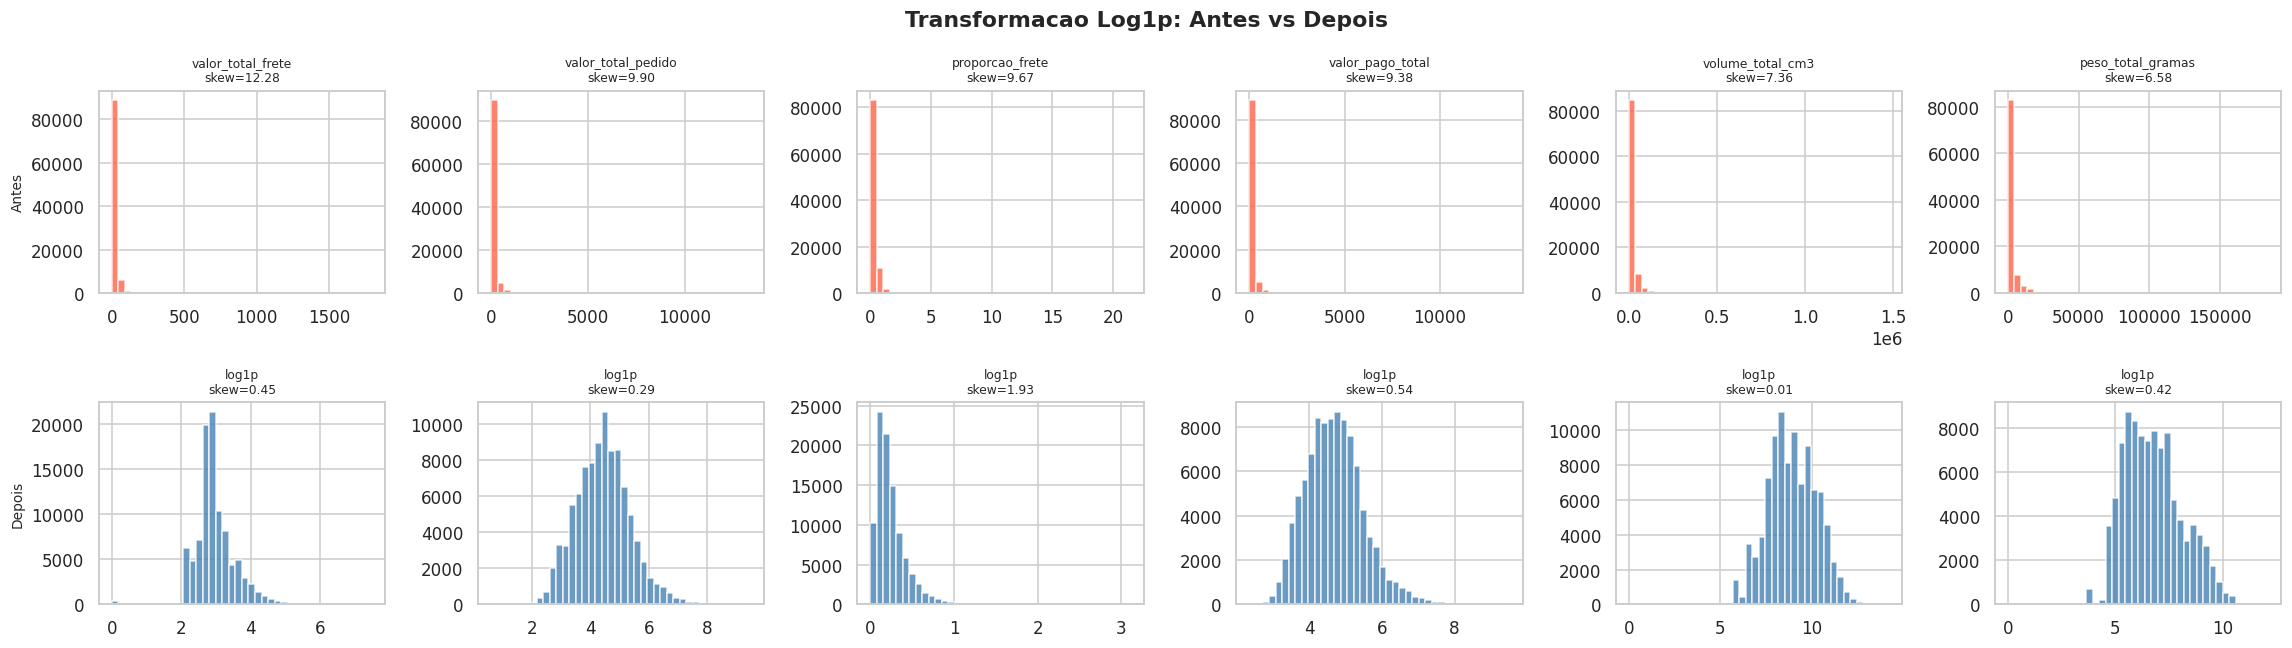

Features transformadas com log1p (10):
Feature                              Skew Antes   Skew Depois
--------------------------------------------------------------
valor_total_frete                        +12.28        +0.45
valor_total_pedido                        +9.90        +0.29
proporcao_frete                           +9.67        +1.93
valor_pago_total                          +9.38        +0.54
volume_total_cm3                          +7.36        +0.01
peso_total_gramas                         +6.58        +0.42
horas_ate_aprovacao                       +4.43        +0.98
distancia_km                              +1.70        -1.05
total_pedidos_vendedor                    +1.65        -0.32
media_dias_entrega_vendedor               +1.59        -0.25


In [5]:
# Features candidatas (excluir binarias, ordinais curtas, ciclicas)
nao_log = [
    'dias_entrega', 'eh_fim_de_semana', 'multiplos_vendedores', 'mesmo_estado',
    'tem_descricao', 'dia_semana_compra', 'mes_compra', 'hora_compra',
    'qtd_itens', 'qtd_vendedores', 'qtd_parcelas', 'qtd_tipos_pagamento', 'media_qtd_fotos'
]
candidatas = [
    c for c in df.select_dtypes(include='number').columns
    if c not in nao_log
]

# Identificar features com cauda longa positiva e min >= 0
features_log = []
for col in candidatas:
    sk = df[col].skew()
    if sk > 1 and df[col].min() >= 0:
        features_log.append((col, round(sk, 3)))

if not features_log:
    print('Nenhuma feature com skewness positivo > 1. Nenhuma transformacao aplicada.')
else:
    cols_log = [c for c, _ in features_log]

    # Snapshot antes da transformacao
    snap_pre = df[cols_log].copy()

    # Aplicar log1p
    for col, _ in features_log:
        df[col] = np.log1p(df[col])

    # Visualizacao: histogramas antes x depois (top 6 mais assimetricos)
    n_show = min(6, len(features_log))
    top_features = sorted(features_log, key=lambda x: abs(x[1]), reverse=True)[:n_show]

    fig, axes = plt.subplots(2, n_show, figsize=(n_show * 3.5, 6), squeeze=False)
    fig.suptitle('Transformacao Log1p: Antes vs Depois', fontweight='bold')

    for i, (col, sk_a) in enumerate(top_features):
        sk_d = df[col].skew()
        axes[0, i].hist(snap_pre[col].dropna(), bins=40, color='tomato',
                        edgecolor='white', alpha=0.8)
        axes[0, i].set_title(f'{col[:18]}\nskew={sk_a:.2f}', fontsize=8)
        if i == 0: axes[0, i].set_ylabel('Antes', fontsize=9)

        axes[1, i].hist(df[col].dropna(), bins=40, color='steelblue',
                        edgecolor='white', alpha=0.8)
        axes[1, i].set_title(f'log1p\nskew={sk_d:.2f}', fontsize=8)
        if i == 0: axes[1, i].set_ylabel('Depois', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Tabela resumo
    print(f'Features transformadas com log1p ({len(features_log)}):')
    print(f'{"Feature":<35s}  Skew Antes   Skew Depois')
    print('-' * 62)
    for col, sk_a in sorted(features_log, key=lambda x: abs(x[1]), reverse=True):
        sk_d = df[col].skew()
        print(f'{col:<35s}  {sk_a:>+10.2f}   {sk_d:>+10.2f}')

## 5. Encoding das Categoricas

In [6]:
# 5a. One-Hot Encoding (baixa cardinalidade)
cat_ohe = [c for c in ['tipo_pagamento', 'regiao_cliente'] if c in df.columns]
df = pd.get_dummies(df, columns=cat_ohe, drop_first=False, dtype=int)

cols_ohe_novas = [c for c in df.columns
                  if any(c.startswith(p + '_') for p in cat_ohe)]
print(f'One-Hot Encoding em: {cat_ohe}')
print(f'  Colunas criadas ({len(cols_ohe_novas)}): {cols_ohe_novas}')

# 5b. Target Encoding (alta cardinalidade ou muitas categorias)
# Mapeamento: media de dias_entrega por categoria
cat_target = [
    c for c in ['categoria_produto', 'customer_state', 'seller_state', 'seller_id']
    if c in df.columns
]
target_maps = {}
media_global = df['dias_entrega'].mean()

for col in cat_target:
    media_por_cat = df.groupby(col)['dias_entrega'].mean()
    target_maps[col] = media_por_cat.to_dict()
    novo = col + '_enc'
    df[novo] = df[col].map(media_por_cat).fillna(media_global)
    df = df.drop(columns=col)
    print(f'Target Encoding: {col} -> {novo}  ({media_por_cat.shape[0]} categorias)')

print(f'\nShape apos encoding: {df.shape[0]:,} x {df.shape[1]}')
print(f'\nColunas atuais:')
for i, c in enumerate(df.columns, 1):
    print(f'  {i:2d}. {c}')


One-Hot Encoding em: ['tipo_pagamento', 'regiao_cliente']
  Colunas criadas (9): ['tipo_pagamento_boleto', 'tipo_pagamento_credit_card', 'tipo_pagamento_debit_card', 'tipo_pagamento_voucher', 'regiao_cliente_Centro-Oeste', 'regiao_cliente_Nordeste', 'regiao_cliente_Norte', 'regiao_cliente_Sudeste', 'regiao_cliente_Sul']
Target Encoding: categoria_produto -> categoria_produto_enc  (72 categorias)
Target Encoding: customer_state -> customer_state_enc  (27 categorias)
Target Encoding: seller_state -> seller_state_enc  (22 categorias)
Target Encoding: seller_id -> seller_id_enc  (2959 categorias)

Shape apos encoding: 96,411 x 39

Colunas atuais:
   1. dias_entrega
   2. hora_compra
   3. dia_semana_compra
   4. mes_compra
   5. eh_fim_de_semana
   6. horas_ate_aprovacao
   7. horas_ate_transportadora
   8. qtd_itens
   9. qtd_vendedores
  10. valor_total_pedido
  11. valor_total_frete
  12. multiplos_vendedores
  13. proporcao_frete
  14. peso_total_gramas
  15. volume_total_cm3
  16. med

## 6. Normalizacao e Padronizacao

In [7]:
# Colunas que NAO serao normalizadas
prefixos_ohe = [c for c in cat_ohe]   # tipo_pagamento, regiao_cliente
binarias = ['eh_fim_de_semana', 'multiplos_vendedores', 'mesmo_estado', 'tem_descricao']
ciclicas  = ['dia_semana_compra', 'mes_compra']

cols_nao_escalar = (
    [c for c in df.columns if any(c.startswith(p + '_') for p in prefixos_ohe)] +
    binarias + ciclicas + ['dias_entrega']
)

cols_escalar = [
    c for c in df.select_dtypes(include='number').columns
    if c not in cols_nao_escalar
]

print(f'Colunas que serao normalizadas ({len(cols_escalar)}):')
for c in sorted(cols_escalar):
    print(f'  - {c}')

print(f'\nColunas que NAO serao normalizadas:')
for c in sorted([cc for cc in df.columns if cc not in cols_escalar and cc != 'dias_entrega']):
    print(f'  - {c}')

print('\nO StandardScaler sera treinado no X_train e aplicado em X_train e X_test.')

Colunas que serao normalizadas (23):
  - categoria_produto_enc
  - customer_state_enc
  - distancia_km
  - hora_compra
  - horas_ate_aprovacao
  - horas_ate_transportadora
  - media_avaliacao_vendedor
  - media_dias_entrega_vendedor
  - media_qtd_fotos
  - peso_por_item
  - peso_total_gramas
  - proporcao_frete
  - qtd_itens
  - qtd_parcelas
  - qtd_tipos_pagamento
  - qtd_vendedores
  - seller_id_enc
  - seller_state_enc
  - total_pedidos_vendedor
  - valor_pago_total
  - valor_total_frete
  - valor_total_pedido
  - volume_total_cm3

Colunas que NAO serao normalizadas:
  - dia_semana_compra
  - eh_fim_de_semana
  - mes_compra
  - mesmo_estado
  - multiplos_vendedores
  - regiao_cliente_Centro-Oeste
  - regiao_cliente_Nordeste
  - regiao_cliente_Norte
  - regiao_cliente_Sudeste
  - regiao_cliente_Sul
  - tem_descricao
  - tipo_pagamento_boleto
  - tipo_pagamento_credit_card
  - tipo_pagamento_debit_card
  - tipo_pagamento_voucher

O StandardScaler sera treinado no X_train e aplicado em

## 7. Separar X e y — Train/Test Split

In [8]:
# Separar X e y
X = df.drop('dias_entrega', axis=1)
y = df['dias_entrega']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Tamanhos do split:')
print(f'  Total:   {len(df):,} amostras')
print(f'  Treino:  {len(X_train):,}  ({len(X_train)/len(df)*100:.0f}%)')
print(f'  Teste:   {len(X_test):,}   ({len(X_test)/len(df)*100:.0f}%)')
print(f'\nFeatures: {X.shape[1]}')
print(f'Target:   dias_entrega')
print(f'  Treino — media: {y_train.mean():.2f}  desvio: {y_train.std():.2f}')
print(f'  Teste  — media: {y_test.mean():.2f}  desvio: {y_test.std():.2f}')

# Normalizar: fit APENAS no treino, transform em ambos
X_train = X_train.copy()
X_test  = X_test.copy()

scaler = StandardScaler()
X_train[cols_escalar] = scaler.fit_transform(X_train[cols_escalar])
X_test[cols_escalar]  = scaler.transform(X_test[cols_escalar])

print('\nStandardScaler aplicado.')

# Salvar datasets e scaler
os.makedirs(PASTA, exist_ok=True)
X_train.to_csv(PASTA + 'X_train.csv', index=False)
X_test.to_csv( PASTA + 'X_test.csv',  index=False)
y_train.to_csv(PASTA + 'y_train.csv', index=False)
y_test.to_csv( PASTA + 'y_test.csv',  index=False)
joblib.dump(scaler,      PASTA + 'scaler.pkl')
joblib.dump(target_maps, PASTA + 'target_encoders.pkl')

print(f'\nArquivos salvos em {PASTA}:')
print(f'  X_train.csv         {X_train.shape[0]:,} x {X_train.shape[1]}')
print(f'  X_test.csv          {X_test.shape[0]:,}  x {X_test.shape[1]}')
print(f'  y_train.csv         {y_train.shape[0]:,}')
print(f'  y_test.csv          {y_test.shape[0]:,}')
print(f'  scaler.pkl')
print(f'  target_encoders.pkl')

Tamanhos do split:
  Total:   96,411 amostras
  Treino:  77,128  (80%)
  Teste:   19,283   (20%)

Features: 38
Target:   dias_entrega
  Treino — media: 12.50  desvio: 9.01
  Teste  — media: 12.45  desvio: 8.93

StandardScaler aplicado.

Arquivos salvos em ./archive/:
  X_train.csv         77,128 x 38
  X_test.csv          19,283  x 38
  y_train.csv         77,128
  y_test.csv          19,283
  scaler.pkl
  target_encoders.pkl


## Resumo Final

In [9]:
print('=' * 65)
print('  RESUMO DO PRE-PROCESSAMENTO')
print('=' * 65)
print(f'\nDataset original:     {df_raw.shape[0]:,} x {df_raw.shape[1]}')
print(f'Dataset final:        {df.shape[0]:,} x {df.shape[1]}')
print(f'  Linhas removidas:   {df_raw.shape[0] - df.shape[0]:,}')
print(f'  Features finais:    {X.shape[1]} features + 1 target')

print(f'\nPasso 1 — Limpeza conservadora')
print('  - Duplicatas removidas')
print('  - Linhas com target invalido removidas')
print('  - Linhas com nulos/brancos removidas')
print('  - Outliers validos preservados')

print(f'\nPasso 2 — Features removidas: {len(removidos)}')
for c in removidos:
    print(f'  - {c}')

print(f'\nPasso 3 — Outliers')
print('  Winsorization/clip desativado: nenhum valor valido foi cortado.')

print(f'\nPasso 4 — Log1p aplicado: {len(features_log)} features')
for col, sk in features_log:
    print(f'  - {col}')

print(f'\nPasso 5 — Encoding')
print(f'  One-Hot: {cat_ohe}  ->  {len(cols_ohe_novas)} colunas')
print(f'  Target:  {cat_target}')

print(f'\nPasso 6 — StandardScaler: {len(cols_escalar)} features')

print(f'\nPasso 7 — Split 80/20')
print(f'  Treino: {len(X_train):,}  |  Teste: {len(X_test):,}')

print(f'\nFeatures prontas para o modelo ({X.shape[1]}):')
for i, c in enumerate(sorted(X.columns), 1):
    print(f'  {i:2d}. {c}')

print('\n' + '=' * 65)
print('  Proximo passo: modelo_olist.ipynb')
print('=' * 65)


  RESUMO DO PRE-PROCESSAMENTO

Dataset original:     96,412 x 34
Dataset final:        96,411 x 39
  Linhas removidas:   1
  Features finais:    38 features + 1 target

Passo 1 — Limpeza conservadora
  - Duplicatas removidas
  - Linhas com target invalido removidas
  - Linhas com nulos/brancos removidas
  - Outliers validos preservados

Passo 2 — Features removidas: 2
  - order_id (identificador unico)
  - customer_id (identificador unico)

Passo 3 — Outliers
  Winsorization/clip desativado: nenhum valor valido foi cortado.

Passo 4 — Log1p aplicado: 10 features
  - horas_ate_aprovacao
  - valor_total_pedido
  - valor_total_frete
  - proporcao_frete
  - peso_total_gramas
  - volume_total_cm3
  - distancia_km
  - valor_pago_total
  - media_dias_entrega_vendedor
  - total_pedidos_vendedor

Passo 5 — Encoding
  One-Hot: ['tipo_pagamento', 'regiao_cliente']  ->  9 colunas
  Target:  ['categoria_produto', 'customer_state', 'seller_state', 'seller_id']

Passo 6 — StandardScaler: 23 features
